<a href="https://colab.research.google.com/github/pramodj551-oss/google-play-analysis/blob/main/google_play_data_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import os
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# set style for visualizations

In [8]:
# step1 : LOAD & Diagnose Data
print("---Step1:Loading Datset ---")
df_raw = pd.read_csv("/content/googleplaystore.csv")

---Step1:Loading Datset ---


In [9]:
print(f"dataset shape: {df_raw.shape}")
print("\n---DataFrame Info ---")
df_raw.info()

dataset shape: (10841, 13)

---DataFrame Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


In [10]:
print("\n---Discriptive Stats(Numeric)----")
print(df_raw.describe(include='all'))



---Discriptive Stats(Numeric)----
           App Category       Rating Reviews                Size    Installs  \
count    10841    10841  9367.000000   10841               10841       10841   
unique    9660       34          NaN    6002                 462          22   
top     ROBLOX   FAMILY          NaN       0  Varies with device  1,000,000+   
freq         9     1972          NaN     596                1695        1579   
mean       NaN      NaN     4.193338     NaN                 NaN         NaN   
std        NaN      NaN     0.537431     NaN                 NaN         NaN   
min        NaN      NaN     1.000000     NaN                 NaN         NaN   
25%        NaN      NaN     4.000000     NaN                 NaN         NaN   
50%        NaN      NaN     4.300000     NaN                 NaN         NaN   
75%        NaN      NaN     4.500000     NaN                 NaN         NaN   
max        NaN      NaN    19.000000     NaN                 NaN         NaN   

    

In [11]:
print("\n---Missing Values Count Per Column ---")
missing_counts = df_raw.isnull().sum()
print(missing_counts[missing_counts > 0])


---Missing Values Count Per Column ---
Rating            1474
Type                 1
Content Rating       1
Current Ver          8
Android Ver          3
dtype: int64


In [12]:
# Step 2 : Clean Dataset
print("\n--- Step 2: Cleaning Dataset ---")
df = df_raw.copy()


--- Step 2: Cleaning Dataset ---


In [13]:
# 1.Drop Dupicates rows
df = df.drop_duplicates()
print(f"Shape After Removing Duplicates: {df.shape}")

Shape After Removing Duplicates: (10358, 13)


In [14]:
# 2. Fix known corrupt row in the google play dataset
if '1.9' in df['Category'].values:
    # This 'if' block was empty, causing a SyntaxError.
    # A common way to handle the corrupt row where 'Category' is '1.9' is to drop it.
    df = df[df['Category'] != '1.9']
    print(f"Dropped corrupt row(s) where Category was '1.9'. New shape: {df.shape}")

Dropped corrupt row(s) where Category was '1.9'. New shape: (10357, 13)


In [15]:
#3. handle column types & stray characters
# Clean 'Reviews' & Convert To Numeric
df['Reviews'] = pd.to_numeric(df['Reviews'], errors='coerce')

In [16]:
import numpy as np
import pandas as pd

# Clean 'Size': Strip 'M', 'K', and handle 'Varies with device'
def clean_size(val):
  if pd.isna(val) or val == 'Varies with device':
    return np.nan
  val = str(val).upper().strip()
  if 'M' in val:
    return float(val.replace('M', ''))
  elif 'K' in val:
    return float(val.replace('K', '')) / 1024
  # If it's neither 'M', 'K', nor 'Varies with device', treat as NaN
  return np.nan

In [17]:
# Apply clean_size function to 'Size' column
df['Size'] = df['Size'].apply(clean_size)
print("Cleaned 'Size' column info:")
df['Size'].info()

Cleaned 'Size' column info:
<class 'pandas.core.series.Series'>
Index: 10357 entries, 0 to 10840
Series name: Size
Non-Null Count  Dtype  
--------------  -----  
8831 non-null   float64
dtypes: float64(1)
memory usage: 161.8 KB


In [18]:
# Clean 'Installs': strip '+', ',' and convert to numeric
df['Installs'] = df['Installs'].astype(str).str.replace('[+,]', '', regex=True)
df['Installs'] = pd.to_numeric(df['Installs'], errors='coerce')
print("Cleaned 'Installs' column info:")
df['Installs'].info()

Cleaned 'Installs' column info:
<class 'pandas.core.series.Series'>
Index: 10357 entries, 0 to 10840
Series name: Installs
Non-Null Count  Dtype
--------------  -----
10357 non-null  int64
dtypes: int64(1)
memory usage: 161.8 KB


In [19]:
# Clean 'Price': remove '$' and convert to numeric
df['Price'] = df['Price'].astype(str).str.replace('$', '', regex=False)
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')
print("Cleaned 'Price' column info:")
df['Price'].info()

Cleaned 'Price' column info:
<class 'pandas.core.series.Series'>
Index: 10357 entries, 0 to 10840
Series name: Price
Non-Null Count  Dtype  
--------------  -----  
10357 non-null  float64
dtypes: float64(1)
memory usage: 161.8 KB


In [20]:
# 4. Missing Valule Strategy Implementation
# Strategy Table Evalution
# Impute Heavy Missing Value Using median
rating_median = df['Rating'].median()
df['Rating'] = df['Rating'].fillna(rating_median)

size_median = df['Size'].median()
df['Size'] = df['Size'].fillna(size_median)

df['Type'] = df['Type'].fillna(df['Type'].mode()[0])

df['Content Rating'] = df['Content Rating'].fillna(df['Content Rating'].mode()[0])

In [21]:
# Drop rows for fields with minimal missing items
df = df.dropna(subset=['Type', 'Content Rating', 'Current Ver', 'Android Ver', 'Installs', 'Price'])
print(f"Shape after missing values managment: {df.shape}")

Shape after missing values managment: (10347, 13)


In [22]:
import numpy as np
import pandas as pd

# 5. Outlier Treatment using IQR Method
# Target Column: 'Price' And 'Reviews'
def treat_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[column] = np.where((df[column] < lower_bound) | (df[column] > upper_bound), np.nan, df[column])
    return df

In [23]:
def treat_outliers_iqr(df, column, action='remove'):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    if action == 'cap':
        df[column] = np.where(df[column] < lower_bound, lower_bound, df[column])
        df[column] = np.where(df[column] > upper_bound, upper_bound, df[column])
    else: # Default to 'remove' (set to NaN)
        df[column] = np.where((df[column] < lower_bound) | (df[column] > upper_bound), np.nan, df[column])
    return df

In [24]:
# Apply outlier treatment to 'Price' and 'Reviews'
df = treat_outliers(df, 'Price')
df = treat_outliers(df, 'Reviews')

print("Shape after outlier treatment:")
print(df.shape)
print("\nMissing values after outlier treatment:")
print(df[['Price', 'Reviews']].isnull().sum())

Shape after outlier treatment:
(10347, 13)

Missing values after outlier treatment:
Price       762
Reviews    1869
dtype: int64


In [25]:
print("Descriptive statistics for 'Price' and 'Reviews' after outlier treatment:")
print(df[['Price', 'Reviews']].describe())

Descriptive statistics for 'Price' and 'Reviews' after outlier treatment:
        Price        Reviews
count  9585.0    8478.000000
mean      0.0   11005.765747
std       0.0   22286.945385
min       0.0       0.000000
25%       0.0      16.000000
50%       0.0     400.000000
75%       0.0    9146.750000
max       0.0  116079.000000


In [26]:
# STEP 3: SQL DATABASE INTEGRATON & QUERY PIPELINE
print("\n--- Step 3: SQL Database Integration & Query Pipeline ---")
# Connect tolocal SQLite DB
db_path = "google_play_apps.db"
conn = sqlite3.connect(db_path)
cursor = conn.cursor()


--- Step 3: SQL Database Integration & Query Pipeline ---


In [27]:
# Expoert Clean DataFrame To SQL
df_sql = df.copy()
df_sql.to_sql('apps', conn, if_exists='replace', index=False)

10347

In [28]:
df_sql.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159.0,19.0,10000,Free,0.0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967.0,14.0,500000,Free,0.0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510.0,8.7,5000000,Free,0.0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,NaN,25.0,50000000,Free,0.0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967.0,2.8,100000,Free,0.0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [29]:
df_sql.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10347 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10347 non-null  object 
 1   Category        10347 non-null  object 
 2   Rating          10347 non-null  float64
 3   Reviews         8478 non-null   float64
 4   Size            10347 non-null  float64
 5   Installs        10347 non-null  int64  
 6   Type            10347 non-null  object 
 7   Price           9585 non-null   float64
 8   Content Rating  10347 non-null  object 
 9   Genres          10347 non-null  object 
 10  Last Updated    10347 non-null  object 
 11  Current Ver     10347 non-null  object 
 12  Android Ver     10347 non-null  object 
dtypes: float64(4), int64(1), object(8)
memory usage: 1.4+ MB


In [30]:
df_sql.describe()


,Rating,Reviews,Size,Installs,Price
count,10347.000000,8478.000000,10347.000000,1.034700e+04,9585.0
mean,4.203779,11005.765747,20.081216,1.417129e+07,0.0
std,0.485707,22286.945385,21.024156,8.027714e+07,0.0
min,1.000000,0.000000,0.008301,0.000000e+00,0.0
25%,4.100000,16.000000,5.700000,1.000000e+03,0.0
50%,4.300000,400.000000,13.000000,1.000000e+05,0.0
75%,4.500000,9146.750000,26.000000,1.000000e+06,0.0
max,5.000000,116079.000000,100.000000,1.000000e+09,0.0


In [31]:
df_sql.shape

(10347, 13)

In [32]:
df_sql.isnull().sum()

,0
App,0
Category,0
Rating,0
Reviews,1869
Size,0
Installs,0
Type,0
Price,762
Content Rating,0
Genres,0


In [33]:
df_sql.columns = [c.replace(' ', '_').lower() for c in df_sql.columns]
df_sql.to_sql('apps', conn, if_exists='replace', index=False)

10347

In [34]:
# Define the 6 Queries fulfilling all Query Constraints
queries ={"Q1_ Where_Filter":
          """SELECT App, Category, Rating, Price FROM apps Where Price Between 1.0 and 4.99 LIMIT 5;""",
          "Q2_Aggregate_Group":
          """SELECT Category, COUNT (*) as Total_Apps FROM apps GROUP BY Category;""",
          "Q3_Having_Filter":
          """SELECT Category, COUNT (*) as Total_Apps FROM apps GROUP BY Category HAVING Total_Apps > 200;""",
          "Q4_Multi_Condition_AND_OR":
          '''SELECT App, Category, Installs, Type FROM apps WHERE (Category = 'Game' OR Category = 'FAMILY')AND INSTALLS >= 10000000 LIMIT 5;''',
          "Q5_Order_By_Limit":
          """SELECT App, Rating, Reviews FROM apps WHERE Type = 'Free' ORDER BY Rating DESC, REviews DESC LIMIT 5;""",
          "Q6_Complex_Aggregation":
          """SELECT Type,MIN(Price) AS Min_Price, MAX(Price) AS Max_Price, AVG(Price) AS Avg_Price FROM apps GROUP BY Type;"""}


In [35]:
# Execute, Verify, and Display Result
for name,sql in queries.items():
    print(f"\n--- Executing Query: {name} ---")
    res_df = pd.read_sql_query(sql, conn)
    print(res_df)


--- Executing Query: Q1_ Where_Filter ---
Empty DataFrame
Columns: [app, category, rating, price]
Index: []

--- Executing Query: Q2_Aggregate_Group ---
               category  Total_Apps
0        ART_AND_DESIGN          64
1     AUTO_AND_VEHICLES          85
2                BEAUTY          53
3   BOOKS_AND_REFERENCE         229
4              BUSINESS         427
5                COMICS          60
6         COMMUNICATION         366
7                DATING         196
8             EDUCATION         130
9         ENTERTAINMENT         111
10               EVENTS          64
11               FAMILY        1940
12              FINANCE         360
13       FOOD_AND_DRINK         124
14                 GAME        1121
15   HEALTH_AND_FITNESS         306
16       HOUSE_AND_HOME          80
17   LIBRARIES_AND_DEMO          84
18            LIFESTYLE         373
19  MAPS_AND_NAVIGATION         137
20              MEDICAL         408
21   NEWS_AND_MAGAZINES         264
22            PARE

In [36]:
# STEP 4; DATA VISUALIZATION
print("\n--- Step 4: Data Visualization ---")
os.makedirs('plots', exist_ok=True)


--- Step 4: Data Visualization ---


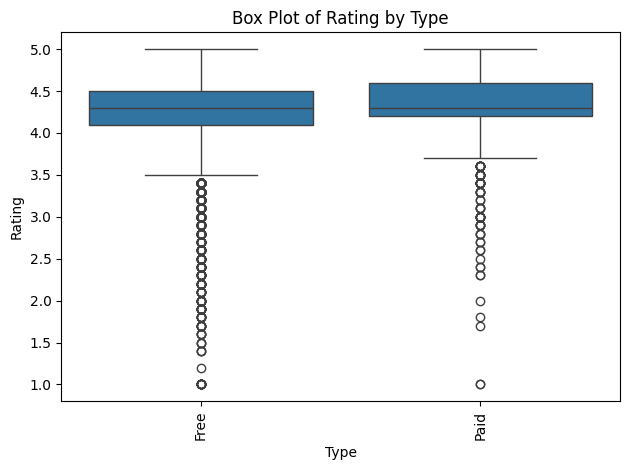

In [39]:
import seaborn as sns
# Chart 1: Box Plot
plt.figure()
sns.boxplot(x='Type', y='Rating', data=df)
plt.title('Box Plot of Rating by Type')
plt.xlabel('Type')
plt.ylabel('Rating')
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig('plots/chart1_boxplot.png')
plt.show()

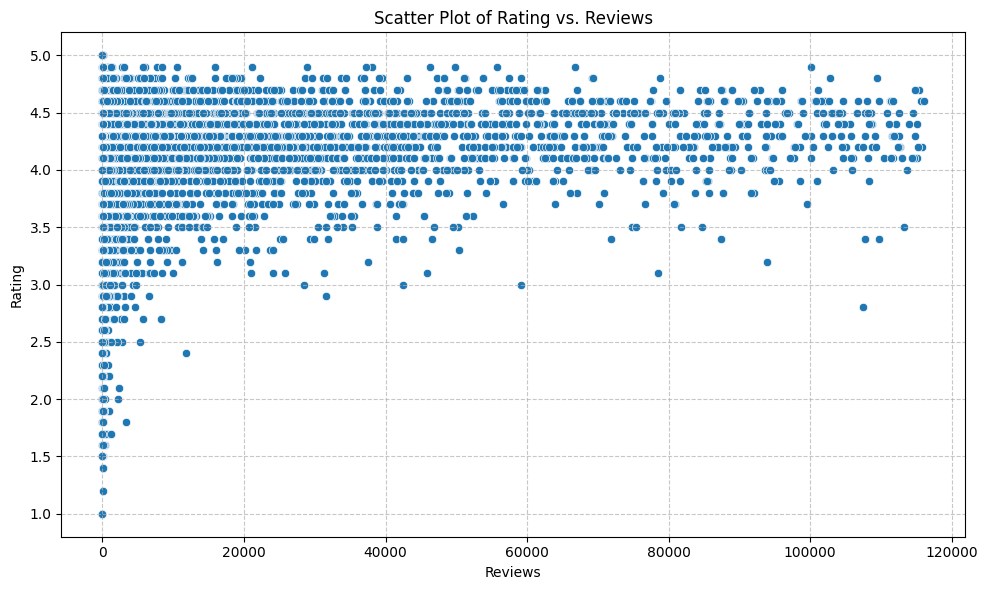

In [40]:
# Chart 2: Scatter Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Reviews', y='Rating', data=df)
plt.title('Scatter Plot of Rating vs. Reviews')
plt.xlabel('Reviews')
plt.ylabel('Rating')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('plots/chart2_scatterplot.png')
plt.show()

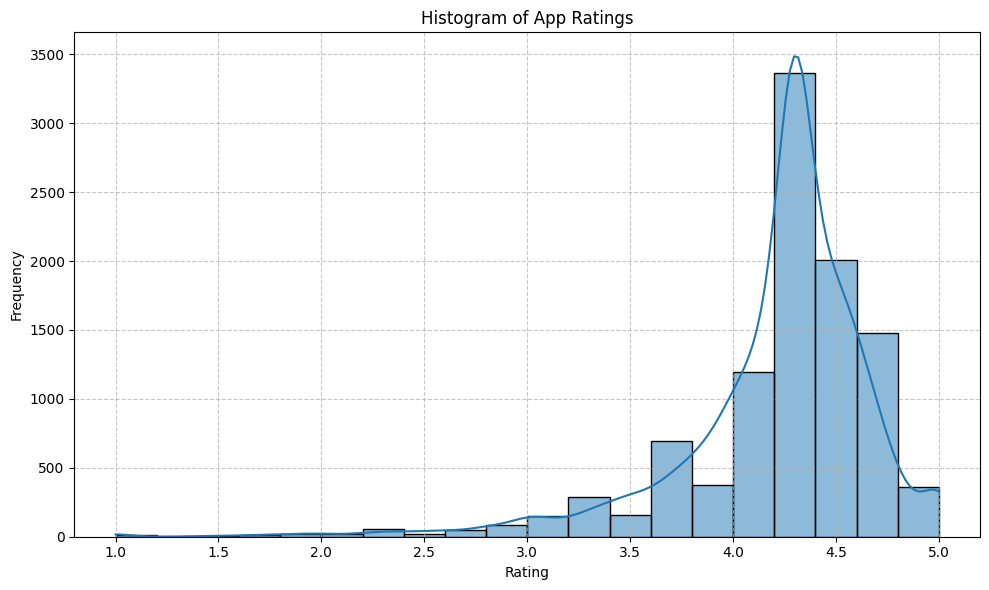

In [41]:
# Chart 3: Histogram
plt.figure(figsize=(10, 6))
sns.histplot(df['Rating'], bins=20, kde=True)
plt.title('Histogram of App Ratings')
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('plots/chart3_histogram.png')
plt.show()

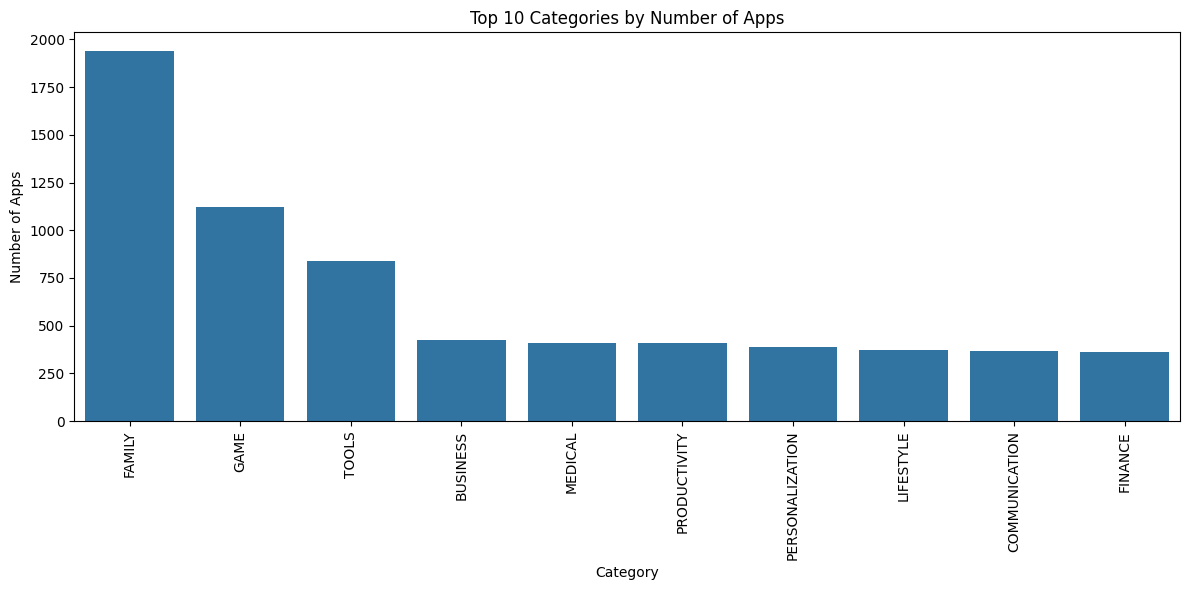

In [42]:
# Chart 4 : Bar Chart
plt.figure(figsize=(12, 6))
sns.countplot(x='Category', data=df, order=df['Category'].value_counts().index[:10])
plt.title('Top 10 Categories by Number of Apps')
plt.xlabel('Category')
plt.ylabel('Number of Apps')
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig('plots/chart4_barchart.png')
plt.show()

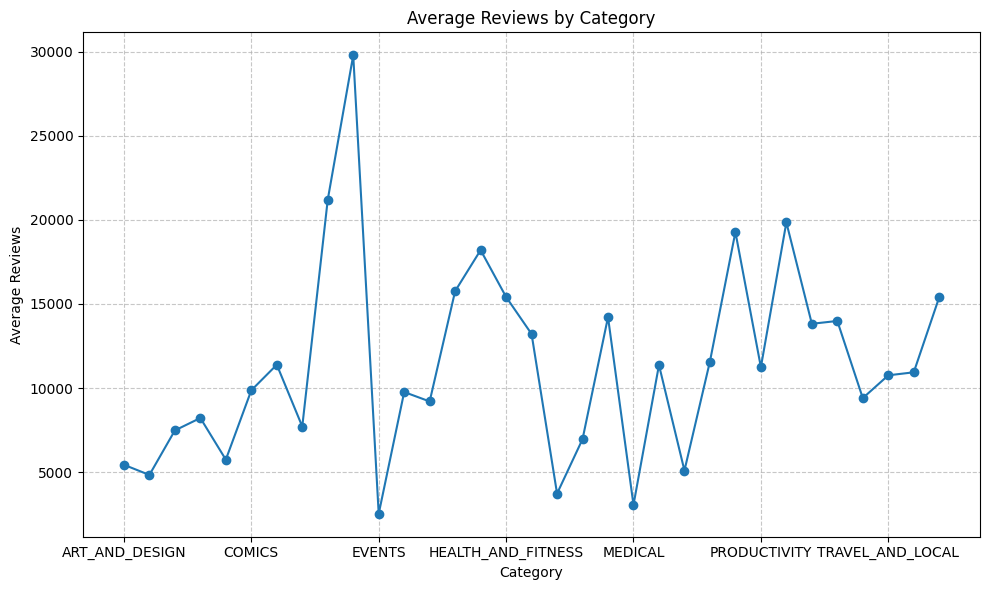

In [43]:
# Chart 5 : Aggregation line Chart
plt.figure(figsize=(10, 6))
df.groupby('Category')['Reviews'].mean().plot(kind='line', marker='o')
plt.title('Average Reviews by Category')
plt.xlabel('Category')
plt.ylabel('Average Reviews')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('plots/chart5_linechart.png')
plt.show()